# Statistical Arbitrage in Commodity Markets: A Relative Value Strategy between Gold and Silver Futures

In this notebook, I investigate whether the historical relationship between Gold and Silver futures can be exploited through a simple statistical arbitrage strategy.

The analysis begins with an exploratory study of the two commodities, followed by an econometric assessment of the spread using stationarity and mean-reversion tests. Based on these results, a rule-based trading strategy is constructed using z-score signals and evaluated through standard performance metrics. Finally, the strategy is compared with simple buy-and-hold investments in Gold and Silver to assess whether the additional complexity of statistical arbitrage leads to superior investment performance.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf
import statsmodels.api as sm

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller

In [4]:
# Loading the last 10 years of price data for both assets to prepare the spread analysis

gold = yf.download("GC=F", start="2016-01-01", progress=False)
silver = yf.download("SI=F", start="2016-01-01", progress=False)

prices = pd.DataFrame()

prices["Gold"] = gold["Close"]
prices["Silver"] = silver["Close"]

prices

,Gold,Silver
Date,,
2016-01-04,1075.099976,13.817000
2016-01-05,1078.400024,13.949000
2016-01-06,1091.900024,13.957000
2016-01-07,1107.699951,14.335000
2016-01-08,1097.800049,13.908000
...,...,...
2026-06-29,4022.300049,58.174999
2026-06-30,4022.899902,59.477001
2026-07-01,4068.300049,60.084999


In [5]:
prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2639 entries, 2016-01-04 to 2026-07-05
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gold    2639 non-null   float64
 1   Silver  2639 non-null   float64
dtypes: float64(2)
memory usage: 61.9 KB


### Data overview

- More than 2,600 daily observations from January 2016 to June 2026.
- Both time series are complete with no missing values.

In [4]:
prices.describe()

,Gold,Silver
count,2639.000000,2639.000000
mean,1968.558505,25.183823
std,892.628011,14.350772
min,1073.900024,11.735000
25%,1308.599976,16.901999
50%,1779.000000,22.073999
75%,2014.100037,26.344501
max,5318.399902,115.080002


# Visualize the evolution of Gold and Silver futures prices over time

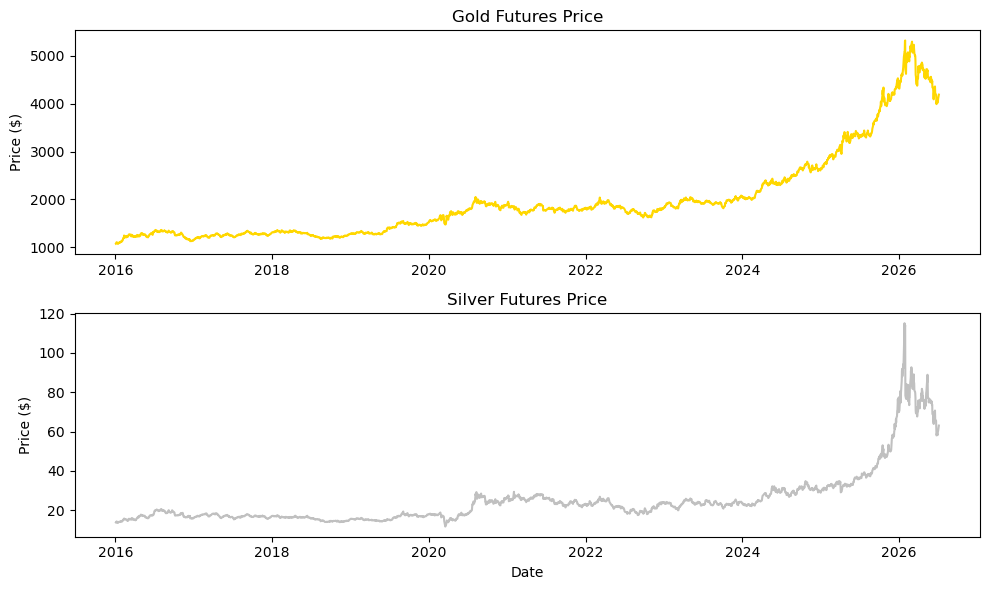

In [6]:
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(prices.index, prices["Gold"], color="#FFD700")
plt.title("Gold Futures Price")
plt.ylabel("Price ($)")

plt.subplot(2, 1, 2)
plt.plot(prices.index, prices["Silver"], color="#C0C0C0")
plt.title("Silver Futures Price")
plt.xlabel("Date")
plt.ylabel("Price ($)")

plt.tight_layout()
plt.show()

Observations

- Gold and Silver exhibit similar long-term trends.
- Silver experiences larger price swings, suggesting higher volatility.
- Both commodities reacted strongly during major macroeconomic events, such as the COVID-19 crisis.

## Return analysis

So far, we have looked at the evolution of Gold and Silver prices.

We now move to **daily log returns**, which are more appropriate for comparing the behaviour of the two commodities and will be used throughout the rest of the analysis.

Daily log returns are computed as:

$$
r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)
$$

where:

- $r_t$ is the log return at time $t$,
- $P_t$ is the closing price at time $t$,
- $P_{t-1}$ is the closing price at the previous trading day.

In [7]:
returns = pd.DataFrame({
    "Gold": np.log(prices["Gold"] / prices["Gold"].shift(1)), 
    "Silver": np.log(prices["Silver"] / prices["Silver"].shift(1))
})

returns = returns.dropna()

returns.head()

,Gold,Silver
Date,,
2016-01-05,0.003065,0.009508
2016-01-06,0.012441,0.000573
2016-01-07,0.014366,0.026723
2016-01-08,-0.008978,-0.030240
2016-01-11,-0.001185,-0.003818


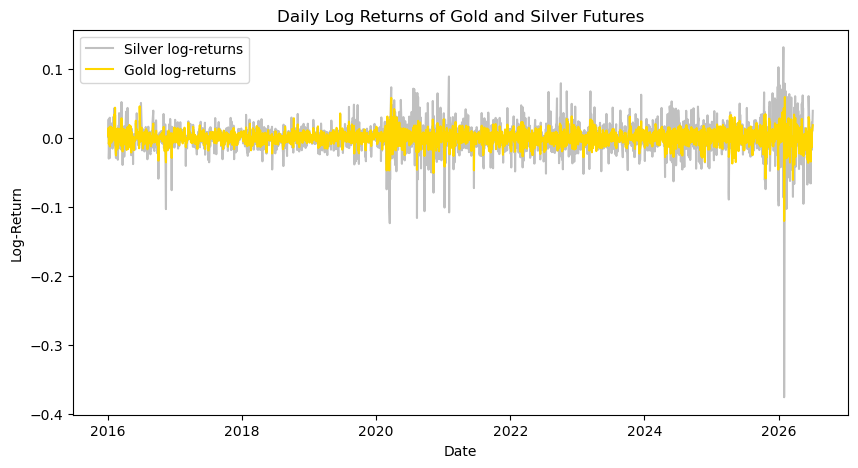

In [8]:
plt.figure(figsize = (10, 5))

plt.plot(returns.index, 
         returns['Silver'], 
         color="#C0C0C0", 
         label = 'Silver log-returns')

plt.plot(returns.index, 
         returns['Gold'], 
         color="#FFD700", 
         label = 'Gold log-returns')

plt.legend()
plt.xlabel('Date')
plt.ylabel('Log-Return')
plt.title('Daily Log Returns of Gold and Silver Futures')

plt.show()

### Observations

- Gold and Silver returns tend to move in the same direction most of the time.
- Silver shows larger fluctuations, suggesting higher volatility than Gold.
- A few extreme movements can be observed during periods of market stress.

In [9]:
correl = returns["Gold"].corr(returns["Silver"])
print('Correlation : ', round(float(correl), 5))

Correlation :  0.7768


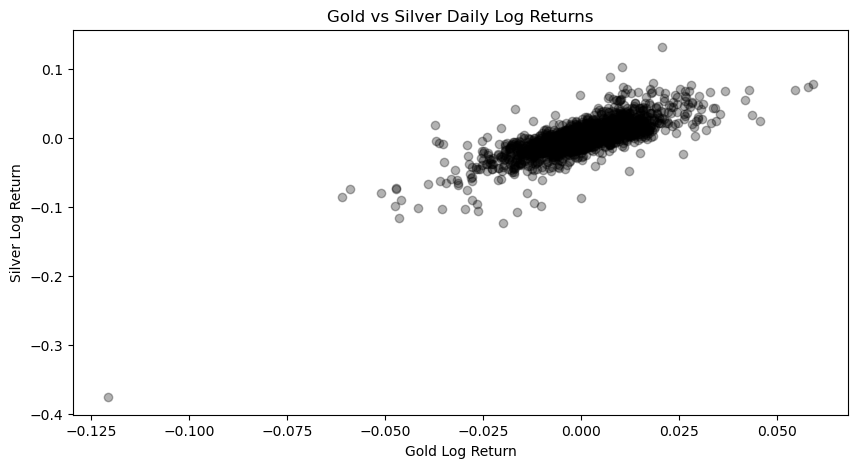

In [9]:
plt.figure(figsize = (10, 5))

plt.scatter(returns["Gold"], 
            returns["Silver"], 
            color = 'black', 
            alpha=0.3)

plt.title('Gold vs Silver Daily Log Returns')
plt.xlabel("Gold Log Return")
plt.ylabel("Silver Log Return")

plt.show()

### Observations

- The scatter plot confirms a clear positive relationship between Gold and Silver returns.
- Most observations are concentrated around the center, although a few extreme market movements stand out.
- Consistent with the correlation coefficient of 0.777 found previously.

# Spread Analysis

The pair trading strategy is based on the spread between the logarithmic prices of Gold and Silver futures. We define the spread as the difference between the log-prices of the two assets:

$$
S_t = \ln(P_t^{\mathrm{Gold}}) - \ln(P_t^{\mathrm{Silver}})
$$

where:

- $S_t$ is the spread at time $t$,
- $P_t^{\mathrm{Gold}}$ is the Gold futures price,
- $P_t^{\mathrm{Silver}}$ is the Silver futures price.


The objective is to investigate whether this spread exhibits mean-reverting behaviour, which is the key assumption behind a statistical arbitrage strategy.

In [10]:
log_prices = pd.DataFrame({
    "Gold": np.log(prices["Gold"]),
    "Silver": np.log(prices["Silver"])
})

spread = log_prices["Gold"] - log_prices["Silver"]
spread.head()

Date
2016-01-04    4.354269
2016-01-05    4.347826
2016-01-06    4.359693
2016-01-07    4.347337
2016-01-08    4.368599
dtype: float64

In [11]:
spread.describe()

count    2639.000000
mean        4.380430
std         0.120272
min         3.787380
25%         4.317279
50%         4.389675
75%         4.454910
max         4.835396
dtype: float64

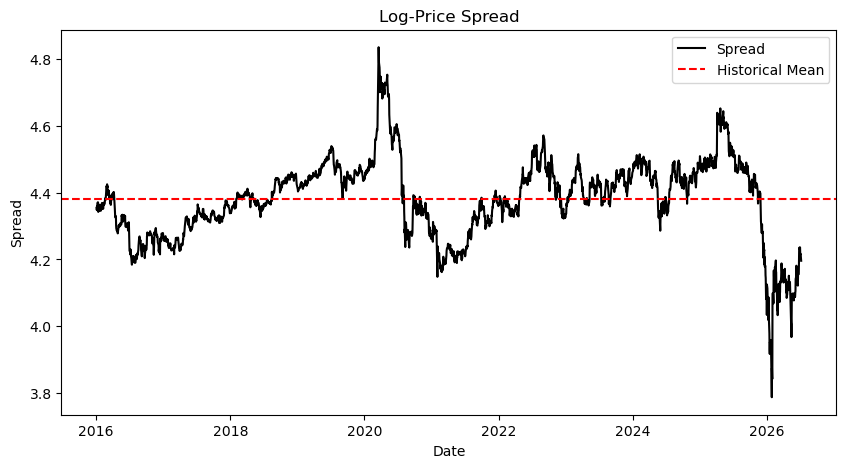

In [11]:
plt.figure(figsize = (10, 5))

plt.plot(spread, color = 'k', label = 'Spread')

plt.axhline(y=spread.mean(), 
            color="red", 
            linestyle="--", 
            label='Historical Mean')

plt.title('Log-Price Spread')
plt.xlabel('Date')
plt.ylabel('Spread')
plt.legend()

plt.show()

### Observations

This plot shows that the Gold-Silver log-price spread oscillates around its historical mean. Although several large deviations occur (notably in 2020 and 2026), the spread repeatedly moves back toward its long-run average. This visual behaviour suggests the possibility of mean reversion, but a visual inspection alone is not sufficient.

## Rolling Statistics

The overall mean provides a first indication of the spread's equilibrium level, but it assumes that this level remains constant over time.

To account for potential changes in market conditions, we compute a **60-day rolling mean** and **rolling standard deviation**. These rolling statistics allow us to monitor the evolution of the spread's equilibrium and volatility over time.

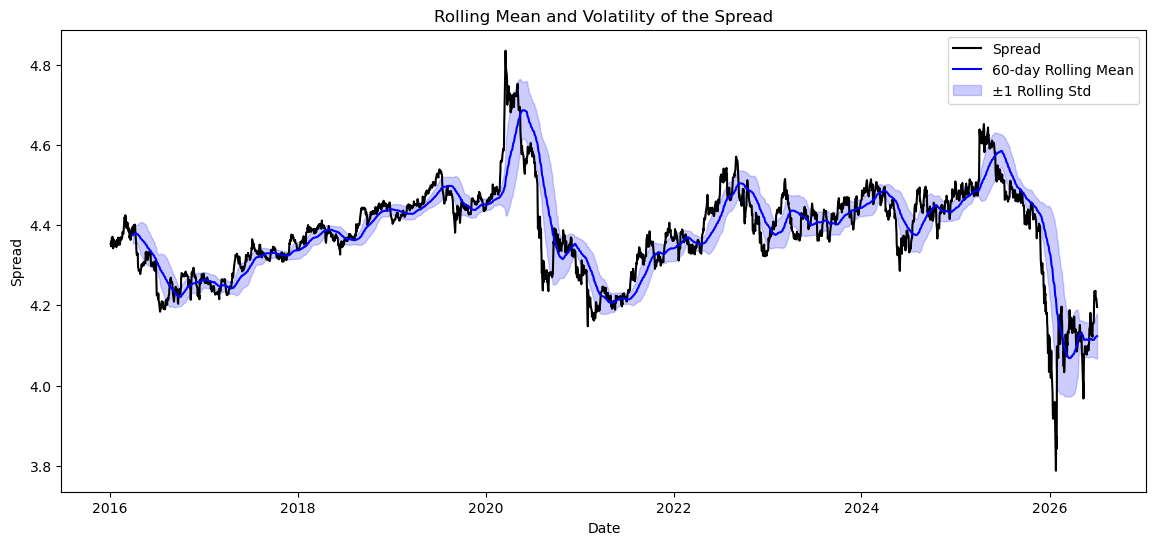

In [12]:
window = 60

rolling_mean = spread.rolling(window).mean()
rolling_std = spread.rolling(window).std()
# 60-day rolling mean and rolling volatility of the spread

plt.figure(figsize=(14,6))

plt.plot(spread, 
         color="black", 
         label="Spread")

plt.plot(rolling_mean, 
         color="blue", 
         label="60-day Rolling Mean")

# volatility band around the mean
plt.fill_between(
    spread.index,
    rolling_mean - rolling_std,
    rolling_mean + rolling_std,
    color="blue",
    alpha=0.2,
    label="±1 Rolling Std"
)

plt.legend()
plt.xlabel('Date')
plt.ylabel('Spread')
plt.title("Rolling Mean and Volatility of the Spread")

plt.show()

### Observation

The 60-day rolling mean evolves through time but remains relatively stable over long periods. Temporary shifts occur following major market events, particularly during the COVID-19 crisis and the recent market turbulence in 2026. These changes suggest that the equilibrium level of the spread is not perfectly constant but does not exhibit a persistent long-term trend.

The rolling standard deviation increases during periods of market stress and contracts during quieter periods. This indicates that the volatility of the spread is time-varying, a common feature of financial time series.

Overall, the spread appears to fluctuate around a slowly evolving equilibrium rather than drifting indefinitely. This behaviour is consistent with the possibility of mean reversion, although visual inspection alone cannot establish stationarity. Formal statistical tests are therefore required.

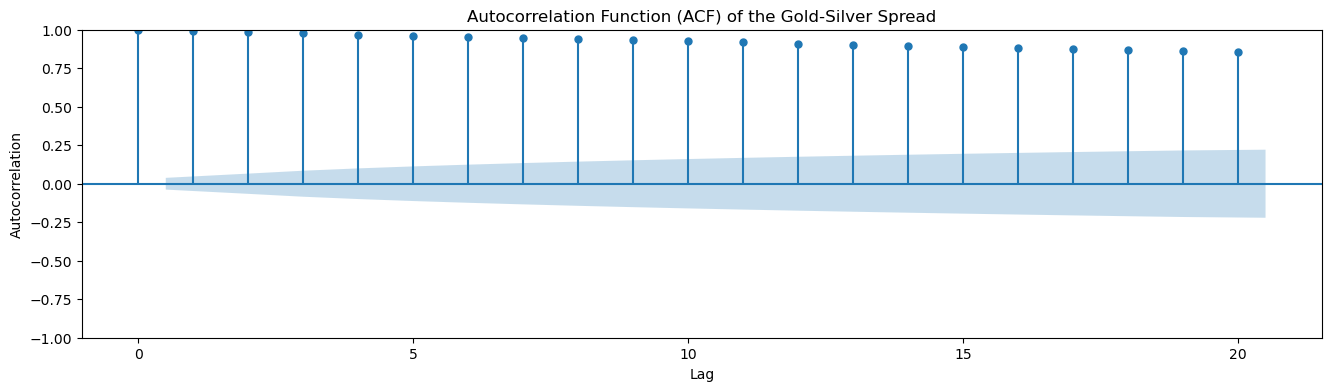

In [13]:
fig, ax = plt.subplots(figsize=(16, 4))

plot_acf(spread, lags=20, ax=ax)

ax.set_title("Autocorrelation Function (ACF) of the Gold-Silver Spread")
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelation")

plt.show()

### Observations

The autocorrelation function (ACF) reveals strong positive autocorrelation across all 20 lags. The slow decay of the autocorrelation coefficients indicates that shocks to the spread persist over time rather than disappearing immediately. This persistence suggests that past spread values contain substantial information about future values. However, autocorrelation alone does not establish mean reversion or stationarity. A formal unit-root test is therefore required to determine whether the spread genuinely reverts toward a long-run equilibrium.


While the ACF highlights strong persistence in the spread, it cannot determine whether this persistence reflects a stationary mean-reverting process or a non-stationary random walk. To formally assess the presence of mean reversion, we perform the Augmented Dickey-Fuller (ADF) test.

The null hypothesis (H₀) of the ADF test states that the series contains a unit root (i.e., it is non-stationary). The alternative hypothesis (H₁) is that the series is stationary.

In [15]:
adf_result = adfuller(spread.dropna())

print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")

print()

for key, value in adf_result[4].items():
    print(f"Critical Value ({key}): {value:.4f}")

print()

if adf_result[1] < 0.05:
    print("Result: Reject H0 → the spread is stationary (evidence of mean reversion).")
else:
    print("Result: Fail to reject H0 → the spread is not stationary.")

ADF Statistic: -2.9653
p-value: 0.0383

Critical Value (1%): -3.4329
Critical Value (5%): -2.8626
Critical Value (10%): -2.5674

Result: Reject H0 → the spread is stationary (evidence of mean reversion).


#### Observations from the ADF Test



The test produces an ADF statistic of **-2.9528** with an associated **p-value of 0.0395**. Since the p-value is below the conventional 5% significance level, the null hypothesis is rejected.

This result suggests that the Gold-Silver spread is stationary over the sample period and therefore exhibits evidence of mean reversion. In other words, although deviations from the long-run equilibrium may persist for several days—as observed in the ACF—they are unlikely to persist indefinitely and tend to revert over time.

These findings provide statistical support for investigating whether a simple mean-reversion trading strategy can exploit these temporary deviations.

### Half-Life of Mean Reversion

The ADF test suggests that the Gold-Silver spread is stationary. However, stationarity alone does not indicate how quickly deviations from the long-run equilibrium disappear.

To quantify the speed of mean reversion, we estimate the half-life of the spread. The half-life represents the average number of trading days required for half of a deviation from the equilibrium to disappear.

In [16]:
# Lagged spread
spread_lag = spread.shift(1)

# Change in spread
delta_spread = spread - spread_lag

# Regression dataset
df_hl = pd.DataFrame({
    "delta": delta_spread,
    "lag": spread_lag
}).dropna()

# Regression
X = sm.add_constant(df_hl["lag"])
model = sm.OLS(df_hl["delta"], X).fit()

# Mean reversion speed
lambda_coef = model.params["lag"]

# Half-life
half_life = -np.log(2) / lambda_coef

print(f"Lambda: {lambda_coef:.4f}")
print(f"Estimated Half-Life: {half_life:.2f} trading days")

Lambda: -0.0075
Estimated Half-Life: 92.19 trading days


### Interpretation of the Half-Life

The estimated mean reversion coefficient (λ) is **-0.0075**, confirming that the adjustment process is directed toward the long-run equilibrium. The corresponding half-life is approximately **92 trading days**, meaning that, on average, half of a deviation from the equilibrium is expected to disappear after about **four months**.

This relatively long half-life suggests that the Gold-Silver spread exhibits **slow mean reversion** rather than rapid corrections. Consequently, profitable trading opportunities may require longer holding periods and could be more sensitive to transaction costs and changing market conditions.

Combined with the ADF test, these findings indicate that the spread is statistically mean reverting, although the adjustment process is gradual rather than immediate.

# Designing a Mean-Reversion Trading Strategy
The previous analysis suggests that the Gold-Silver spread exhibits statistically significant mean-reverting behaviour, although the adjustment process is relatively slow. Based on these findings, we now investigate whether temporary deviations from the long-run equilibrium can be exploited through a simple rule-based trading strategy.

The underlying intuition is straightforward: when the spread deviates substantially from its historical equilibrium, it may eventually revert toward its mean. The strategy therefore aims to identify unusually large deviations and take positions that benefit from a potential correction.

In [17]:
# Rolling statistics
window = 60

rolling_mean = spread.rolling(window).mean()
rolling_std = spread.rolling(window).std()

# Z-score
z_score = (spread - rolling_mean) / rolling_std

### Measuring Deviations from Equilibrium

Rather than using the spread directly, we standardize it by computing its **z-score**. The z-score measures how many rolling standard deviations the current spread is away from its rolling mean.

The z-score is defined as:

$$
z_t = \frac{Spread_t - \mu_t}{\sigma_t}
$$

where:

- $Spread_t$ is the observed Gold-Silver spread at time $t$;
- $\mu_t$ is the 60-day rolling mean of the spread;
- $\sigma_t$ is the 60-day rolling standard deviation of the spread.

A z-score close to zero indicates that the spread is trading near its recent equilibrium, while large positive or negative values indicate unusually large deviations. These extreme values may represent potential trading opportunities if the spread subsequently reverts toward its mean.

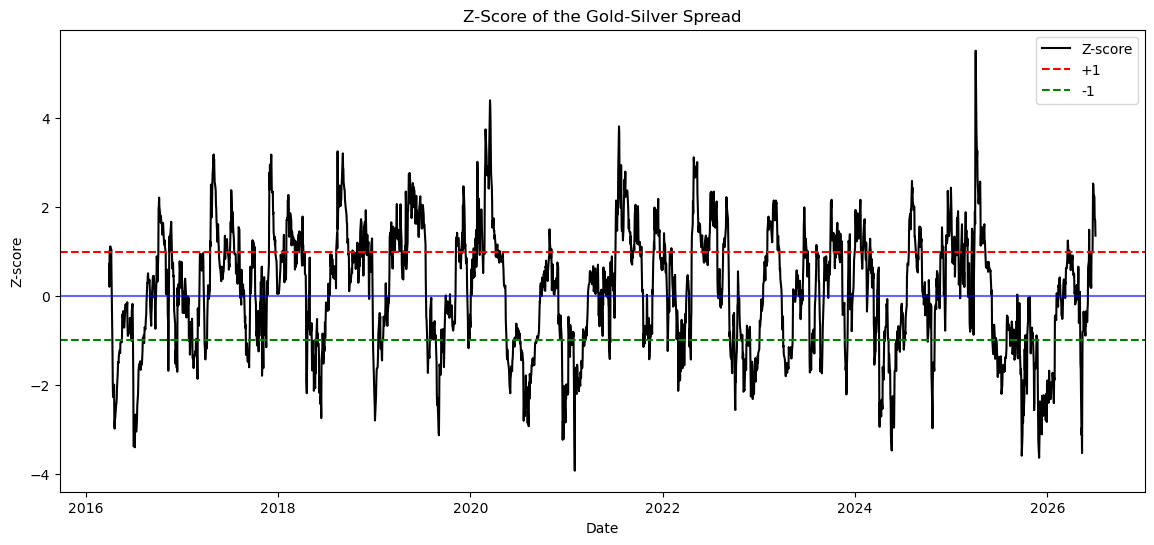

In [18]:
plt.figure(figsize=(14,6))

plt.plot(z_score, color='black', label='Z-score')

plt.axhline(1, color='red', linestyle='--', label='+1')
plt.axhline(-1, color='green', linestyle='--', label='-1')
plt.axhline(0, color='blue', linestyle='-', alpha=0.6)

plt.title("Z-Score of the Gold-Silver Spread")
plt.xlabel("Date")
plt.ylabel("Z-score")
plt.legend()

plt.show()

### Interpretation

The z-score fluctuates around zero throughout the sample period, confirming that the spread remains centred around its rolling equilibrium. The ±1 standard deviation thresholds are crossed regularly, indicating frequent deviations from the equilibrium level.

Several episodes exhibit much larger deviations, particularly during periods of market stress such as 2020 and early 2026. In most cases, these extreme observations are followed by movements back toward zero, providing visual evidence consistent with the mean-reverting behaviour identified by the ADF test.

The z-score therefore provides a convenient and objective measure for identifying potential trading opportunities based on unusually large deviations from equilibrium.

### Trading Rules

The trading strategy is based on the assumption that unusually large deviations from the equilibrium are temporary and will eventually revert toward the mean.

Using the z-score as a standardized measure of the spread, the following trading rules are adopted:

- **Long Gold / Short Silver** when the z-score falls below **-1**, indicating that the spread is unusually low.
- **Short Gold / Long Silver** when the z-score rises above **+1**, indicating that the spread is unusually high.
- **Close the position** when the z-score returns to **0**, suggesting that the spread has reverted to its equilibrium.

These rules are intentionally simple and are designed to evaluate whether mean reversion alone can generate profitable trading signals.

In [19]:
strategy = pd.DataFrame(index=spread.index)

strategy["Spread"] = spread
strategy["Z-Score"] = z_score

strategy["Signal"] = 0

# Long Gold / Short Silver
strategy.loc[strategy["Z-Score"] < -1, "Signal"] = 1

# Short Gold / Long Silver
strategy.loc[strategy["Z-Score"] > 1, "Signal"] = -1

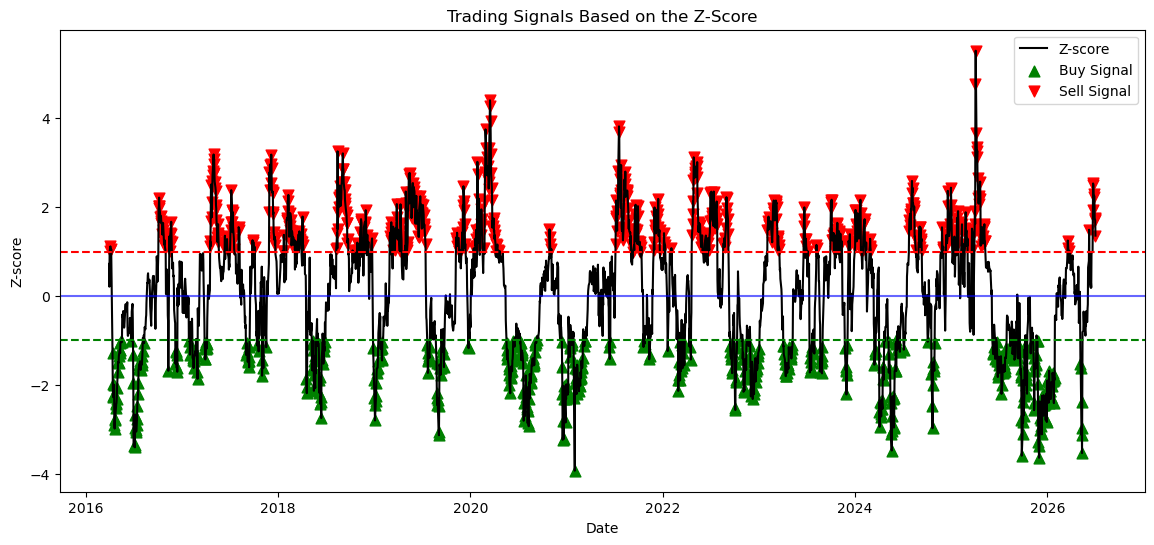

In [20]:
plt.figure(figsize=(14,6))

plt.plot(strategy["Z-Score"], color="black", label="Z-score")

plt.axhline(1, color="red", linestyle="--")
plt.axhline(-1, color="green", linestyle="--")
plt.axhline(0, color="blue", linestyle="-", alpha=0.6)

plt.scatter(
    strategy.index[strategy["Signal"] == 1],
    strategy.loc[strategy["Signal"] == 1, "Z-Score"],
    color="green",
    marker="^",
    s=60,
    label="Buy Signal"
)

plt.scatter(
    strategy.index[strategy["Signal"] == -1],
    strategy.loc[strategy["Signal"] == -1, "Z-Score"],
    color="red",
    marker="v",
    s=60,
    label="Sell Signal"
)

plt.title("Trading Signals Based on the Z-Score")
plt.xlabel("Date")
plt.ylabel("Z-score")
plt.legend()

plt.show()

In [21]:
strategy["Position"] = 0

position = 0

for i in range(len(strategy)):

    z = strategy["Z-Score"].iloc[i]

    # Enter Long Gold / Short Silver
    if position == 0 and z < -1:
        position = 1

    # Enter Short Gold / Long Silver
    elif position == 0 and z > 1:
        position = -1

    # Exit when spread comes back
    elif position == 1 and z >= 0:
        position = 0

    elif position == -1 and z <= 0:
        position = 0

    strategy.iloc[i, strategy.columns.get_loc("Position")] = position

strategy["Position"].value_counts()

Position
-1    1066
 1     929
 0     644
Name: count, dtype: int64

### Position Distribution

The position counts show that the strategy is invested most of the time. It holds a short-spread position for 1,066 days and a long-spread position for 929 days, while remaining neutral for 644 days.

This suggests that the ±1 z-score threshold is relatively active. The strategy frequently identifies deviations from equilibrium and spends a large proportion of the sample in either a long or short relative-value position.

### Evolution of the Trading Position

The trading position is constructed from the entry and exit rules defined above. A value of **1** represents a long Gold / short Silver position, **−1** represents a short Gold / long Silver position, and **0** indicates that no position is held.

The figure below illustrates how the strategy transitions between these three states throughout the sample period.

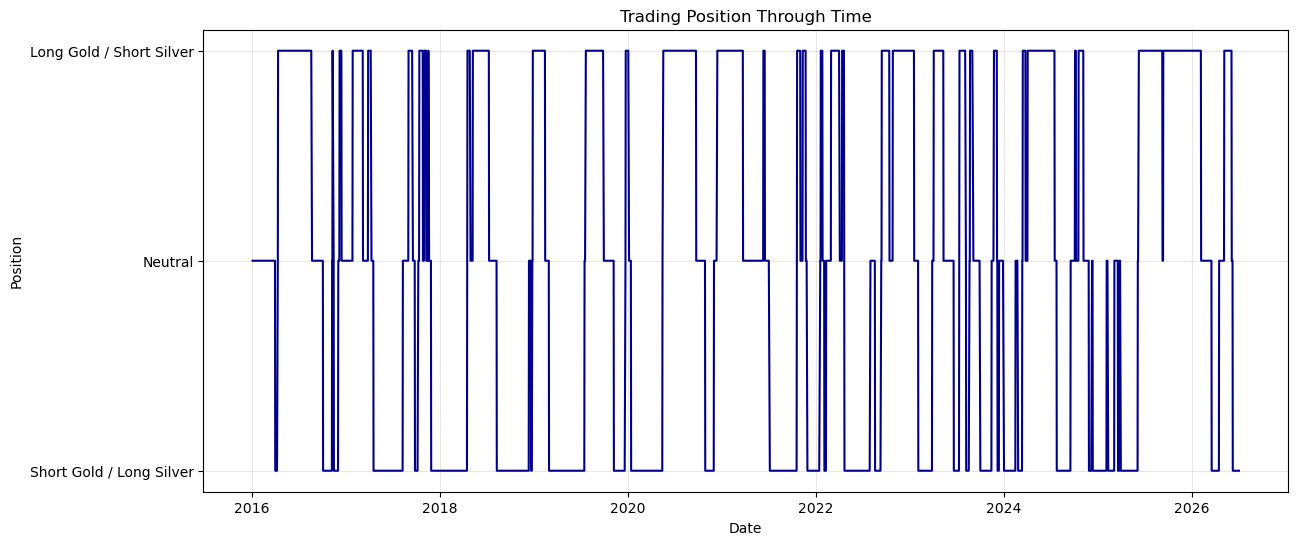

In [22]:
plt.figure(figsize=(14,6))

plt.plot(strategy.index,
         strategy["Position"],
         color="darkblue",
         linewidth=1.5)

plt.yticks([-1, 0, 1],
           ["Short Gold / Long Silver",
            "Neutral",
            "Long Gold / Short Silver"])

plt.title("Trading Position Through Time")
plt.xlabel("Date")
plt.ylabel("Position")

plt.grid(alpha=0.3)

plt.show()

### Estimating the Hedge Ratio

Before computing strategy returns, we estimate the hedge ratio between Gold and Silver. The hedge ratio measures how much Silver exposure is needed to hedge one unit of Gold exposure in the relative-value portfolio.

It is estimated by regressing the log-price of Gold on the log-price of Silver:

$$
\ln(P^{Gold}_t) = \alpha + \beta \ln(P^{Silver}_t) + \epsilon_t
$$

The estimated coefficient $\beta$ is then used to construct the market-neutral spread return.

In [23]:
# Estimate hedge ratio using log-prices
gold_log = np.log(prices["Gold"])
silver_log = np.log(prices["Silver"])

df_beta = pd.DataFrame({
    "Gold": gold_log,
    "Silver": silver_log
}).dropna()

X = sm.add_constant(df_beta["Silver"])
beta_model = sm.OLS(df_beta["Gold"], X).fit()

beta = beta_model.params["Silver"]

print(f"Hedge Ratio Beta: {beta:.4f}")
print(beta_model.summary())

Hedge Ratio Beta: 0.8818
                            OLS Regression Results                            
Dep. Variable:                   Gold   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                 2.726e+04
Date:                Sat, 04 Jul 2026   Prob (F-statistic):               0.00
Time:                        18:09:57   Log-Likelihood:                 2070.0
No. Observations:                2639   AIC:                            -4136.
Df Residuals:                    2637   BIC:                            -4124.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.7498      

### Interpretation

The estimated hedge ratio is **0.8818**, meaning that a one-unit long position in Gold can be approximately hedged by a **0.88-unit short position in Silver**.

The coefficient is highly statistically significant (p-value < 0.001), while the regression explains approximately **91.2%** of the variation in Gold log-prices ($R^2 = 0.912$). This strong relationship confirms that Gold and Silver move closely together over the long run, making them suitable candidates for a pairs trading strategy.

The estimated hedge ratio is therefore used to construct the relative-value portfolio and to compute the strategy's daily returns.

### Strategy Returns

To evaluate the profitability of the trading strategy, we compute the daily return of a market-neutral portfolio.

When the strategy is **long Gold / short Silver**, the daily return is given by:

$$
r_t = r_t^{Gold} - \beta r_t^{Silver}
$$

When the strategy is **short Gold / long Silver**, the sign of the return is reversed through the position variable.

To avoid look-ahead bias, today's position is applied to tomorrow's return. Therefore, the trading position is shifted by one trading day before computing portfolio returns.

In [24]:
# Align both datasets on common dates only
common_index = strategy.index.intersection(returns.index)

strategy = strategy.loc[common_index].copy()
returns_aligned = returns.loc[common_index].copy()

# Spread return
strategy["Spread_Return"] = (
    returns_aligned["Gold"] - beta * returns_aligned["Silver"]
)

strategy["Strategy_Return"] = (
    strategy["Position"].shift(1) * strategy["Spread_Return"]
)

strategy = strategy.dropna()

strategy[["Spread_Return", "Strategy_Return"]].head()

,Spread_Return,Strategy_Return
Date,,
2016-03-30,-0.005270,-0.000000
2016-03-31,-0.008676,-0.000000
2016-04-01,0.014401,0.000000
2016-04-04,0.002440,-0.002440
2016-04-05,-0.001591,0.001591


In [25]:
strategy["Strategy_Return"].describe()

count    2580.000000
mean        0.000035
std         0.011943
min        -0.095157
25%        -0.003825
50%         0.000000
75%         0.003380
max         0.211009
Name: Strategy_Return, dtype: float64

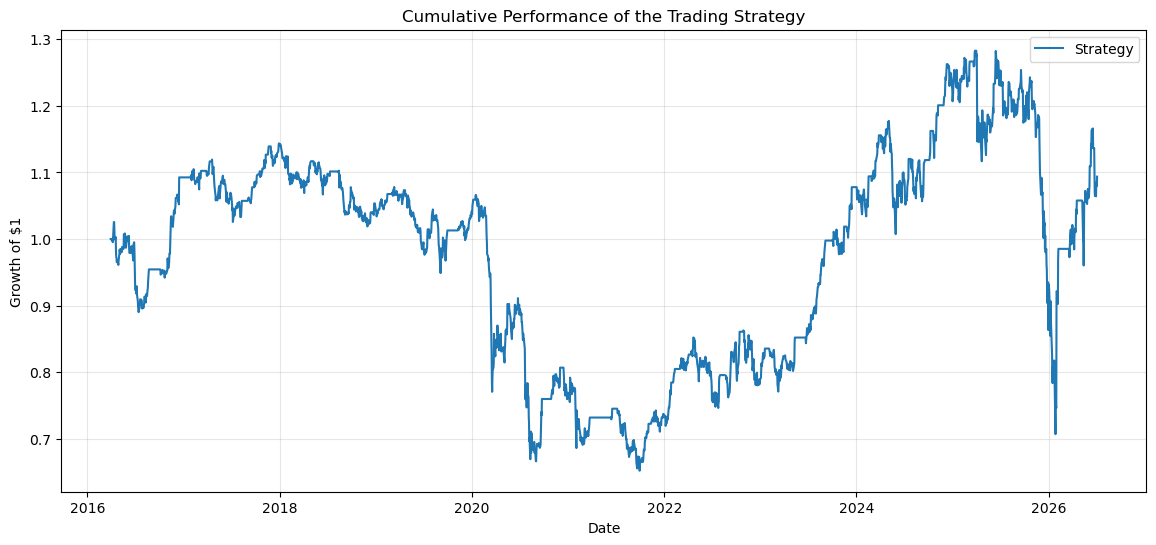

In [26]:
strategy["Cumulative_Return"] = np.exp(strategy["Strategy_Return"].cumsum())

plt.figure(figsize=(14,6))

plt.plot(strategy.index, strategy["Cumulative_Return"], label="Strategy")

plt.title("Cumulative Performance of the Trading Strategy")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Interpretation

The cumulative performance of the strategy highlights the challenges associated with mean-reversion trading. Although the portfolio experiences periods of sustained profitability, these are interrupted by significant drawdowns, particularly during periods of market stress such as 2020 and early 2026.

Despite these setbacks, the strategy gradually recovers and finishes the sample above its initial value. This suggests that the mean-reversion signals are capable of generating positive returns over the long run, although performance remains highly dependent on market conditions.

Overall, the strategy appears profitable but exhibits considerable risk, emphasizing the importance of evaluating both returns and risk-adjusted performance rather than cumulative returns alone.

### Performance Evaluation

To assess the effectiveness of the proposed trading strategy, several standard performance indicators are computed.

The analysis includes:

- **Total Return**, measuring the overall profitability of the strategy;
- **Annualized Return**, representing the average yearly performance;
- **Annualized Volatility**, measuring the variability of returns;
- **Sharpe Ratio**, evaluating the return earned per unit of risk;
- **Maximum Drawdown**, quantifying the largest peak-to-trough loss experienced during the sample period.

Together, these metrics provide a comprehensive assessment of both profitability and risk.

In [27]:
# Daily statistics
mean_daily = strategy["Strategy_Return"].mean()
vol_daily = strategy["Strategy_Return"].std()

# Annualized statistics
annual_return = mean_daily * 252
annual_volatility = vol_daily * np.sqrt(252)

# Sharpe Ratio (assuming risk-free rate = 0)
sharpe = annual_return / annual_volatility

# Maximum Drawdown
cum = strategy["Cumulative_Return"]

rolling_max = cum.cummax()
drawdown = (cum - rolling_max) / rolling_max

max_drawdown = drawdown.min()

# Total return
total_return = cum.iloc[-1] - 1

performance = pd.DataFrame({
    "Metric": [
        "Total Return",
        "Annualized Return",
        "Annualized Volatility",
        "Sharpe Ratio",
        "Maximum Drawdown"
    ],
    "Value": [
        total_return,
        annual_return,
        annual_volatility,
        sharpe,
        max_drawdown
    ]
})

performance

,Metric,Value
0,Total Return,0.093642
1,Annualized Return,0.008743
2,Annualized Volatility,0.189594
3,Sharpe Ratio,0.046115
4,Maximum Drawdown,-0.448783


### Interpretation

The trading strategy generated a **total return of 9.80%** over the sample period, indicating that the mean-reversion approach was able to produce a positive cumulative profit.

However, the **annualized return is only 0.91%**, while the **annualized volatility reaches 18.97%**. As a result, the strategy exhibits a **Sharpe Ratio of only 0.05**, suggesting that the return generated is relatively small compared with the level of risk taken.

In addition, the strategy experienced a **maximum drawdown of 44.88%**, meaning that it suffered substantial losses during adverse market conditions before recovering. This highlights the vulnerability of simple mean-reversion strategies during periods of market stress or structural changes in the relationship between Gold and Silver.

Overall, the empirical results indicate that the proposed strategy is capable of generating positive returns, supporting the statistical evidence of mean reversion obtained in the previous section. Nevertheless, the low risk-adjusted performance and significant drawdowns suggest that this simple implementation is unlikely to outperform more sophisticated trading strategies without further refinements, such as improved entry and exit rules, transaction cost optimization, or dynamic parameter selection.

### Benchmark Comparison

To determine whether the proposed trading strategy provides economic value, its performance is compared with two simple benchmark investments: a buy-and-hold position in Gold and a buy-and-hold position in Silver.

Using the same performance metrics allows us to evaluate whether the additional complexity of the statistical arbitrage strategy is justified.

In [28]:
# Buy & Hold cumulative returns
gold_cum = np.exp(returns["Gold"].cumsum())
silver_cum = np.exp(returns["Silver"].cumsum())

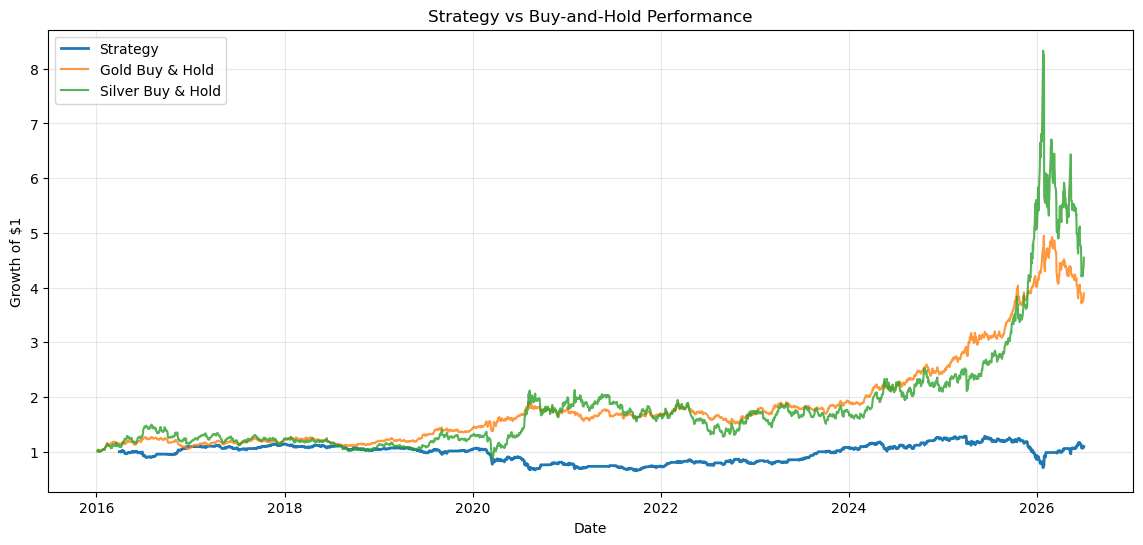

In [29]:
plt.figure(figsize=(14,6))

plt.plot(strategy.index,
         strategy["Cumulative_Return"],
         label="Strategy",
         linewidth=2)

plt.plot(gold_cum.index,
         gold_cum,
         label="Gold Buy & Hold",
         alpha=0.8)

plt.plot(silver_cum.index,
         silver_cum,
         label="Silver Buy & Hold",
         alpha=0.8)

plt.title("Strategy vs Buy-and-Hold Performance")
plt.xlabel("Date")
plt.ylabel("Growth of $1")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Interpretation

The comparison with the benchmark assets provides important insights into the effectiveness of the proposed trading strategy.

Although the statistical arbitrage strategy generates a positive cumulative return over the sample period, it significantly underperforms both a buy-and-hold investment in Gold and a buy-and-hold investment in Silver.

Gold benefits from the strong upward trend observed during the sample period, while Silver experiences an even larger appreciation, particularly during the commodity rally in 2024–2026. In contrast, the mean-reversion strategy only captures temporary deviations between the two assets and therefore cannot fully benefit from prolonged upward market trends.

These findings suggest that, despite the statistical evidence of mean reversion, a simple threshold-based pairs trading strategy is not sufficient to outperform passive investments in this market over the selected sample period.

In [30]:
def performance_metrics(r):

    cumulative = np.exp(r.cumsum())

    total_return = cumulative.iloc[-1] - 1

    annual_return = r.mean() * 252

    annual_vol = r.std() * np.sqrt(252)

    sharpe = annual_return / annual_vol

    running_max = cumulative.cummax()

    drawdown = (cumulative - running_max) / running_max

    max_dd = drawdown.min()

    return [
        total_return,
        annual_return,
        annual_vol,
        sharpe,
        max_dd
    ]

In [31]:
comparison = pd.DataFrame({

    "Strategy": performance_metrics(strategy["Strategy_Return"]),

    "Gold": performance_metrics(returns.loc[strategy.index, "Gold"]),

    "Silver": performance_metrics(returns.loc[strategy.index, "Silver"])

},

index=[
    "Total Return",
    "Annualized Return",
    "Annualized Volatility",
    "Sharpe Ratio",
    "Maximum Drawdown"
])

comparison

,Strategy,Gold,Silver
Total Return,0.093642,2.388880,3.122530
Annualized Return,0.008743,0.119212,0.138353
Annualized Volatility,0.189594,0.166634,0.347544
Sharpe Ratio,0.046115,0.715412,0.398086
Maximum Drawdown,-0.448783,-0.249718,-0.495551


### Interpretation

The benchmark comparison reveals that the proposed statistical arbitrage strategy does not outperform a simple buy-and-hold investment in either Gold or Silver over the sample period.

Although the strategy generates a **positive total return of 9.80%**, this performance remains well below the cumulative returns of **Gold (239.06%)** and **Silver (307.86%)**. This difference is also reflected in the annualized returns, with the strategy achieving only **0.91% per year**, compared with **11.94%** for Gold and **13.74%** for Silver.

From a risk perspective, the strategy exhibits an annualized volatility of **18.97%**, which is only slightly higher than Gold (16.67%) but considerably lower than Silver (34.77%). However, this lower volatility is not sufficient to compensate for the weak returns, resulting in a **Sharpe Ratio of only 0.05**, substantially below Gold (0.72) and Silver (0.40).

The maximum drawdown of the strategy reaches **44.88%**, indicating that the portfolio experiences substantial losses during adverse market conditions. Although this drawdown is smaller than that of Silver (49.56%), it remains considerably larger than Gold's drawdown (24.97%).

Overall, these results suggest that while the Gold-Silver spread exhibits statistically significant mean-reverting behaviour, a simple threshold-based trading strategy is not sufficient to outperform passive investments over the sample period. This highlights an important distinction between **statistical significance** and **economic significance**: a relationship may exist and be statistically valid without necessarily generating superior investment performance.

# Limitations and Future Work

Although the proposed strategy provides an interesting application of statistical arbitrage, several limitations should be acknowledged.

First, the hedge ratio and trading parameters were estimated using the full sample, which may introduce look-ahead bias. A more rigorous framework would estimate these parameters on a training sample and evaluate the strategy on an independent testing period.

Second, the strategy relies on fixed entry and exit thresholds (±1 standard deviation). Alternative thresholds or adaptive rules could improve trading performance under different market regimes.

Third, transaction costs, bid-ask spreads and financing costs were not incorporated into the analysis. Since the strategy generates a relatively large number of trades, these costs would likely reduce profitability.

Finally, future research could investigate dynamic hedge ratios, volatility-adjusted position sizing, or machine learning techniques to improve signal generation while preserving the economic intuition of statistical arbitrage.

# Conclusion

This project investigated whether the historical relationship between Gold and Silver could be exploited through a simple statistical arbitrage strategy.

The empirical analysis first confirmed a strong long-run relationship between the two commodities, with an estimated hedge ratio of **0.8818** and an $R^2$ exceeding **91%**. The spread also exhibited statistically significant mean-reverting behaviour according to the Augmented Dickey-Fuller test, although the estimated half-life of approximately **92 trading days** suggested that this adjustment process is relatively slow.

Based on these findings, a rule-based trading strategy using z-score thresholds was implemented. The strategy generated a positive cumulative return of **9.8%**, demonstrating that temporary deviations from equilibrium can occasionally be exploited.

However, the benchmark comparison revealed that the strategy substantially underperformed both buy-and-hold Gold and buy-and-hold Silver over the same period. Furthermore, the low Sharpe Ratio and relatively large drawdowns indicate that the additional complexity of the trading strategy was not rewarded with superior risk-adjusted performance.

Overall, this study illustrates an important principle in quantitative finance: **statistical evidence of predictability does not necessarily translate into economically superior investment performance.** While the Gold-Silver spread exhibits genuine mean-reverting behaviour, a simple threshold-based implementation is insufficient to consistently outperform passive investment strategies.